# **Импорты**

In [ ]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

%matplotlib inline

# **Загрузка данных**

In [ ]:
# Загрузим датасет из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)
# Распакуем архив в папку writers
!unzip -o writers.zip -d writers/


Archive:  writers.zip
  inflating: writers/(Клиффорд_Саймак) Обучающая_5 вместе.txt  
  inflating: writers/(Клиффорд_Саймак) Тестовая_2 вместе.txt  
  inflating: writers/(Макс Фрай) Обучающая_5 вместе.txt  
  inflating: writers/(Макс Фрай) Тестовая_2 вместе.txt  
  inflating: writers/(О. Генри) Обучающая_50 вместе.txt  
  inflating: writers/(О. Генри) Тестовая_20 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Обучающая_22 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Тестовая_8 вместе.txt  
  inflating: writers/(Стругацкие) Обучающая_5 вместе.txt  
  inflating: writers/(Стругацкие) Тестовая_2 вместе.txt  
  inflating: writers/(Булгаков) Обучающая_5 вместе.txt  
  inflating: writers/(Булгаков) Тестовая_2 вместе.txt  


# **Пути до файлов**

In [ ]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

# **Подготовка списков и добавление текстов**

In [ ]:
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Получим списка файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    # Выделяем имя класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатываем
    if m:

        # Получим имя класса
        class_name = m[1]

        # Получим имя выборки
        subset_name = m[2].lower()

        # Проверим тип выборки
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатываем
        if is_train or is_test:

            # Добавляем новый класс, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)

                # Инициализируем соответствующих классу строки текста
                text_train.append('')
                text_test.append('')

            # Найдем индекс класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')

            # Откроем файл на чтение
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:

                # Загрузим содержимого файла в строку
                text = f.read()
            # Определим выборку, куда будет добавлено содержимое
            subset = text_train if is_train else text_test

            # Добавим текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

Добавление класса "О. Генри"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Обучающая_5 вместе.txt" в класс "Стругацкие", обучающая выборка.
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление файла "(Рэй Брэдберри) Тестовая_8 вмест

<>:12: SyntaxWarning: invalid escape sequence '\('
<>:12: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_649/2214232407.py:12: SyntaxWarning: invalid escape sequence '\('
  m = re.match('\((.+)\) (\S+)_', file_name)


# **Определение количества классов и вывод текстов**

In [ ]:
# Определим количество классов
CLASS_COUNT = len(CLASS_LIST)
# Выведем прочитанные классы текстов
print(CLASS_LIST)
# Посчитаем количество текстов в обучающей выборке
print(len(text_train))
# Проверим загрузки: выведем начальные отрывки из каждого класса

for cls in range(CLASS_COUNT):                   # Запустим цикл по числу классов
    print(f'Класс: {CLASS_LIST[cls]}')           # Выведем имя класса
    print(f'  train: {text_train[cls][:200]}')   # Выведем фрагмент обучающей выборки
    print(f'  test : {text_test[cls][:200]}')    # Выведем фрагмент тестовой выборки
    print()

['О. Генри', 'Рэй Брэдберри', 'Булгаков', 'Клиффорд_Саймак', 'Макс Фрай', 'Стругацкие']
6
Класс: О. Генри
  train:  «Лиса-на-рассвете»   Коралио нежился в полуденном зное, как томная красавица в сурово хранимом гареме. Город лежал у самого моря на полоске наносной земли. Он казался брильянтиком, вкрапленным в ярко
  test :  ﻿Багдадская птица   Без всякого сомнения, дух и гений калифа Гаруна аль-Рашида осенил маркграфа Августа-Михаила фон Паульсена Квигга.  Ресторан Квигга находится на Четвертой авеню — на улице, которую

Класс: Рэй Брэдберри
  train:  ﻿451° по Фаренгейту   ДОНУ КОНГДОНУ С БЛАГОДАРНОСТЬЮ   Если тебе дадут линованную бумагу, пиши поперёк.  Хуан Рамон Хименес   Часть 1  ОЧАГ И САЛАМАНДРА   Жечь было наслаждением. Какое-то особое насл
  test :  ﻿Марсианские хроники   МОЕЙ ЖЕНЕ МАРГАРЕТ С ИСКРЕННЕЙ ЛЮБОВЬЮ   «Великое дело – способность удивляться, – сказал философ. – Космические полеты снова сделали всех нас детьми».   Январь 1999  Ракетное 

Класс: Булгаков
  train:  ﻿Бела

# **Контекстный менеджер**

In [ ]:
# Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with

class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

# **Разбиение текста**

In [ ]:
# Функция для разбиения текста на отрезки (окна)
def get_samples(texts, win_size, win_hop):
    x_samples = []
    y_samples = []

    for i in range(len(texts)):
        text = texts[i]
        # Проходим по тексту с заданным шагом
        for j in range(0, len(text) - win_size + 1, win_hop):
            x_samples.append(text[j:j + win_size])
            y_samples.append(utils.to_categorical(i, CLASS_COUNT))

    return np.array(x_samples), np.array(y_samples)

# **Написание функций**

In [ ]:
# Функция для проведения эксперимента
def run_experiment(vocab_size, win_size, win_hop, epochs=20):
    # Токенизация
    tokenizer = Tokenizer(num_words=vocab_size,
                          filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                          lower=True, split=' ', char_level=False)

    tokenizer.fit_on_texts(text_train)

    # Преобразование текстов в последовательности индексов
    seq_train = tokenizer.texts_to_sequences(text_train)
    seq_test = tokenizer.texts_to_sequences(text_test)

    # Формирование выборок
    x_train, y_train = get_samples(seq_train, win_size, win_hop)
    x_test, y_test = get_samples(seq_test, win_size, win_hop)

    # Создание модели (выбрана Conv1D как одна из наиболее эффективных для данной задачи)
    model = Sequential([
        Embedding(vocab_size, 50, input_length=win_size),
        SpatialDropout1D(0.2),
        BatchNormalization(),
        Conv1D(20, 5, activation='relu'),
        MaxPooling1D(2),
        Dropout(0.2),
        Flatten(),
        Dense(CLASS_COUNT, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Обучение
    with timex():
        history = model.fit(x_train, y_train,
                            epochs=epochs,
                            batch_size=128,
                            validation_data=(x_test, y_test),
                            verbose=0)
        plot_training_history(history)

    # Возвращаем лучшую точность на проверочной выборке
    return max(history.history['val_accuracy'])

# **Проведение первого эксперимента**


Тестирование VOCAB_SIZE = 5000...


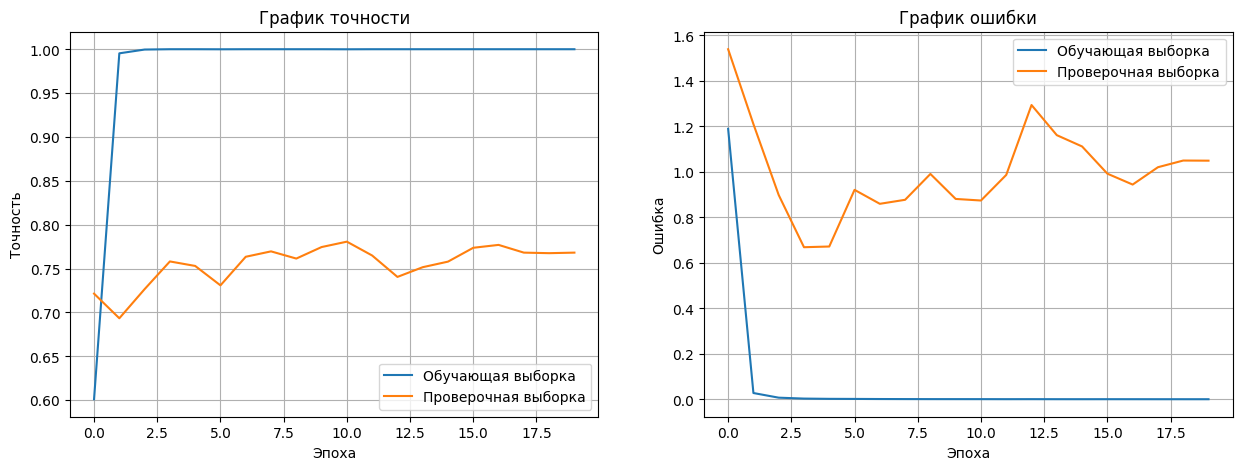

Время обработки: 41.38 с

Тестирование VOCAB_SIZE = 10000...


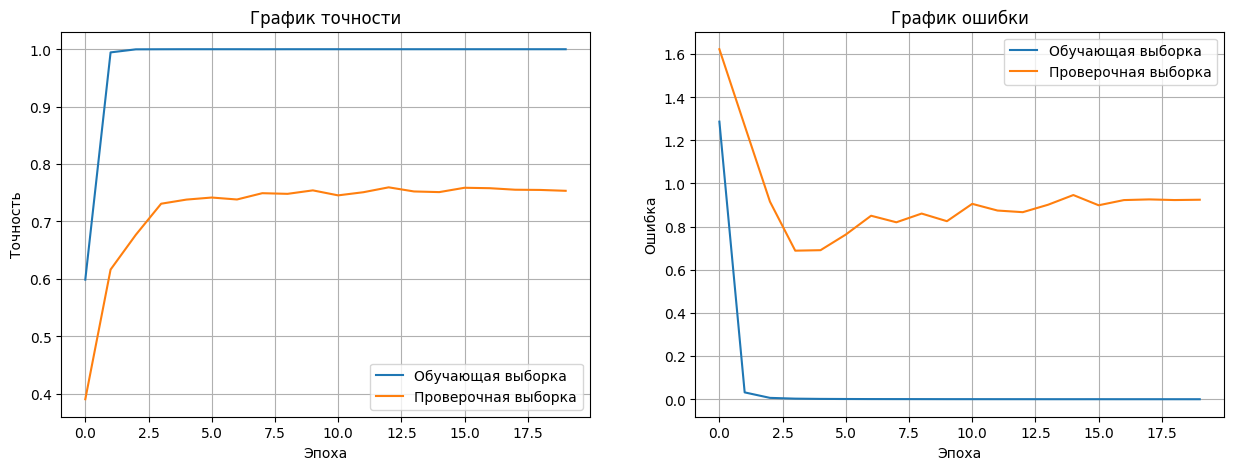

Время обработки: 44.01 с

Тестирование VOCAB_SIZE = 20000...


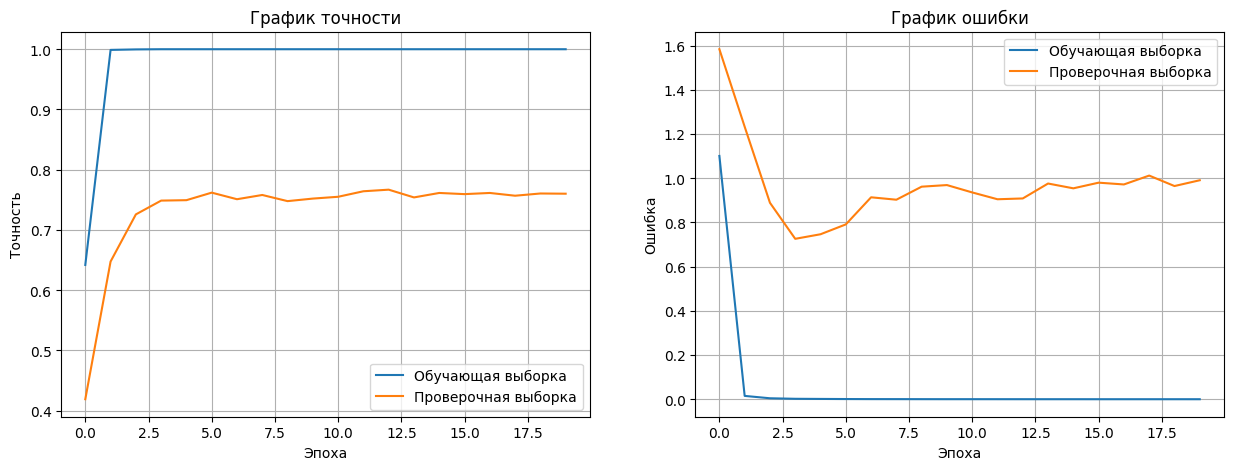

Время обработки: 48.14 с

Тестирование VOCAB_SIZE = 40000...


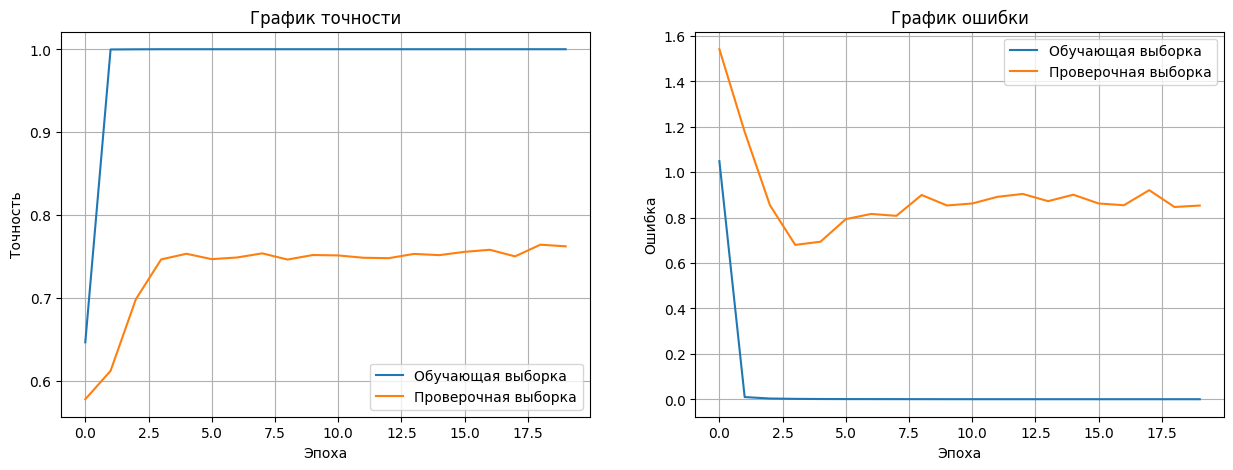

Время обработки: 51.97 с


In [ ]:
results = []

# Изменение VOCAB_SIZE (WIN_SIZE=1000, WIN_HOP=100)
vocab_values = [5000, 10000, 20000, 40000]
for v in vocab_values:
    print(f'\nТестирование VOCAB_SIZE = {v}...')
    acc = run_experiment(v, 1000, 100)
    results.append({'VOCAB_SIZE': v, 'WIN_SIZE': 1000, 'WIN_HOP': 100, 'Accuracy': acc})

# **Проведение второго эксперимента**


Тестирование WIN_SIZE = 500, WIN_HOP = 50...


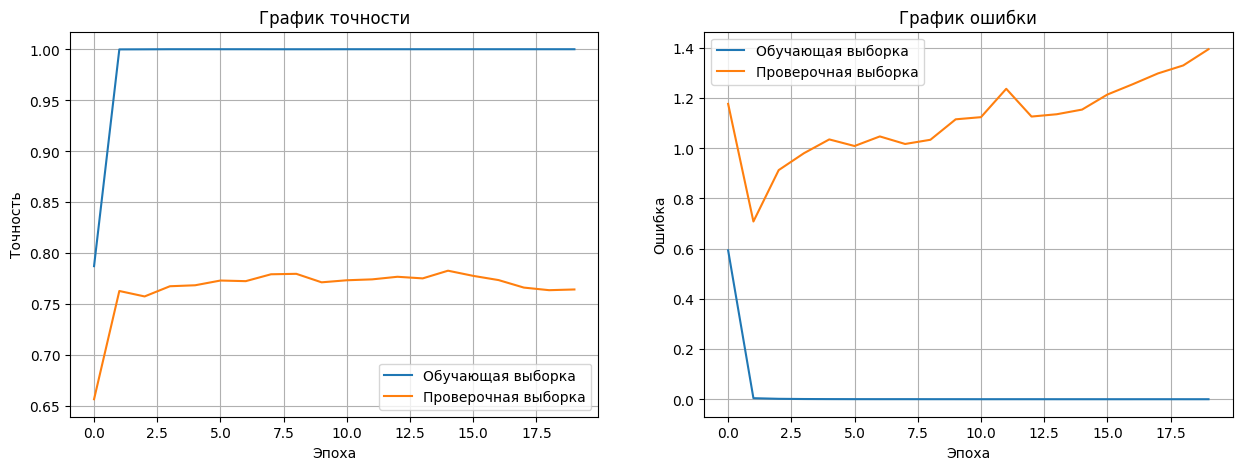

Время обработки: 55.35 с

Тестирование WIN_SIZE = 2000, WIN_HOP = 200...


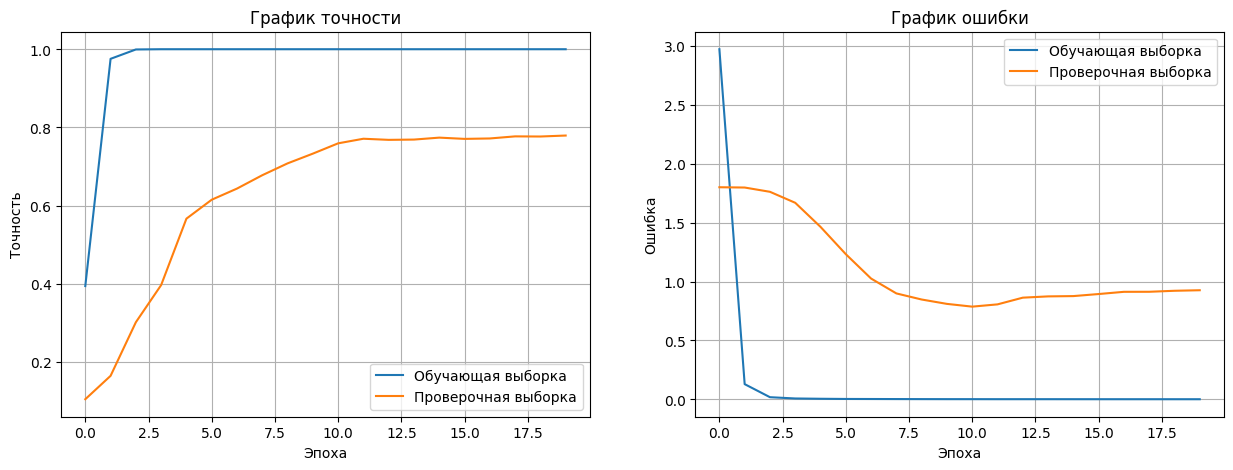

Время обработки: 44.12 с


In [ ]:
window_values = [(500, 50), (2000, 200)]
for w_size, w_hop in window_values:
    print(f'\nТестирование WIN_SIZE = {w_size}, WIN_HOP = {w_hop}...')
    acc = run_experiment(20000, w_size, w_hop)
    results.append({'VOCAB_SIZE': 20000, 'WIN_SIZE': w_size, 'WIN_HOP': w_hop, 'Accuracy': acc})

# **Сводная таблица**

In [ ]:
print('\n{:<12} | {:<10} | {:<10} | {:<10}'.format('VOCAB_SIZE', 'WIN_SIZE', 'WIN_HOP', 'Accuracy'))
print('-' * 50)
for res in results:
    print('{:<12} | {:<10} | {:<10} | {:<10.4f}'.format(
        res['VOCAB_SIZE'], res['WIN_SIZE'], res['WIN_HOP'], res['Accuracy']))


VOCAB_SIZE   | WIN_SIZE   | WIN_HOP    | Accuracy  
--------------------------------------------------
5000         | 1000       | 100        | 0.7806    
10000        | 1000       | 100        | 0.7594    
20000        | 1000       | 100        | 0.7669    
40000        | 1000       | 100        | 0.7643    
20000        | 500        | 50         | 0.7827    
20000        | 2000       | 200        | 0.7793    


In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Создаем полотно для двух графиков
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # 1. График точности (Accuracy)
    ax1.plot(history.history['accuracy'], label='Обучающая выборка')
    ax1.plot(history.history['val_accuracy'], label='Проверочная выборка')
    ax1.set_title('График точности')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Точность')
    ax1.legend()
    ax1.grid(True)

    # 2. График ошибки (Loss)
    ax2.plot(history.history['loss'], label='Обучающая выборка')
    ax2.plot(history.history['val_loss'], label='Проверочная выборка')
    ax2.set_title('График ошибки')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    ax2.grid(True)

    plt.show()